In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:

clinical_data = pd.read_csv(r"D:\GUVI\Projects\Clinical Trial Disease_project5\clinical_trials_raw_patient2trial_conditions.csv")

In [5]:
clinical_data.shape

(60337, 16)

In [6]:
clinical_data.columns

Index(['source_condition_query', 'nct_id', 'title', 'official_title',
       'brief_summary', 'conditions', 'interventions', 'overall_status',
       'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age',
       'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url'],
      dtype='str')

In [7]:
clinical_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  str   
 1   nct_id                  60337 non-null  str   
 2   title                   60337 non-null  str   
 3   official_title          59551 non-null  str   
 4   brief_summary           60337 non-null  str   
 5   conditions              60336 non-null  str   
 6   interventions           54276 non-null  str   
 7   overall_status          60337 non-null  str   
 8   study_type              60337 non-null  str   
 9   phase                   23336 non-null  str   
 10  sex                     60304 non-null  str   
 11  minimum_age             57121 non-null  str   
 12  maximum_age             28400 non-null  str   
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  str   
 15  clinicaltrial

In [15]:
clinical_data.head()

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [14]:
clinical_data.isnull().sum() / clinical_data.shape[0] *100



source_condition_query     0.000000
nct_id                     0.000000
title                      0.000000
official_title             1.302683
brief_summary              0.000000
conditions                 0.001657
interventions             10.045246
overall_status             0.000000
study_type                 0.000000
phase                     61.323897
sex                        0.054693
minimum_age                5.330063
maximum_age               52.931037
healthy_volunteers         2.452890
eligibility_criteria       0.018231
clinicaltrials_url         0.000000
dtype: float64

In [17]:
type(clinical_data)

pandas.DataFrame

In [34]:
clinical_nlp = clinical_data[['brief_summary', 'source_condition_query']].copy()

clinical_nlp.head()

,brief_summary,source_condition_query
0,Breast cancer patients often have perioperativ...,breast cancer
1,Many breast cancer patients experience psychol...,breast cancer
2,"Based on an American study by Scherer et al., ...",breast cancer
3,Compare the effect of ropivacaine versus place...,breast cancer
4,Phase 1 dose escalation and expansion study of...,breast cancer


In [37]:
clinical_nlp.columns = ['summary', 'disease_category']

clinical_nlp.head()

,summary,disease_category
0,Breast cancer patients often have perioperativ...,breast cancer
1,Many breast cancer patients experience psychol...,breast cancer
2,"Based on an American study by Scherer et al., ...",breast cancer
3,Compare the effect of ropivacaine versus place...,breast cancer
4,Phase 1 dose escalation and expansion study of...,breast cancer


In [38]:
clinical_nlp.isnull().sum()

summary             0
disease_category    0
dtype: int64

In [43]:
clinical_nlp.duplicated().sum()

np.int64(265)

In [44]:
print("Before:", clinical_nlp.shape)

clinical_nlp = clinical_nlp.drop_duplicates()

print("After:", clinical_nlp.shape)

Before: (60337, 2)
After: (60072, 2)


In [45]:
disease_counts = clinical_nlp['disease_category'].value_counts()

disease_counts

disease_category
breast cancer                            16265
type 2 diabetes                          11398
covid-19                                 10103
anxiety                                   9260
chronic obstructive pulmonary disease     6142
rheumatoid arthritis                      3618
glaucoma                                  2150
sickle cell anemia                        1136
Name: count, dtype: int64

In [49]:
round(
clinical_nlp['disease_category'].value_counts(normalize=True)*100,
2)

disease_category
breast cancer                            27.08
type 2 diabetes                          18.97
covid-19                                 16.82
anxiety                                  15.41
chronic obstructive pulmonary disease    10.22
rheumatoid arthritis                      6.02
glaucoma                                  3.58
sickle cell anemia                        1.89
Name: proportion, dtype: float64

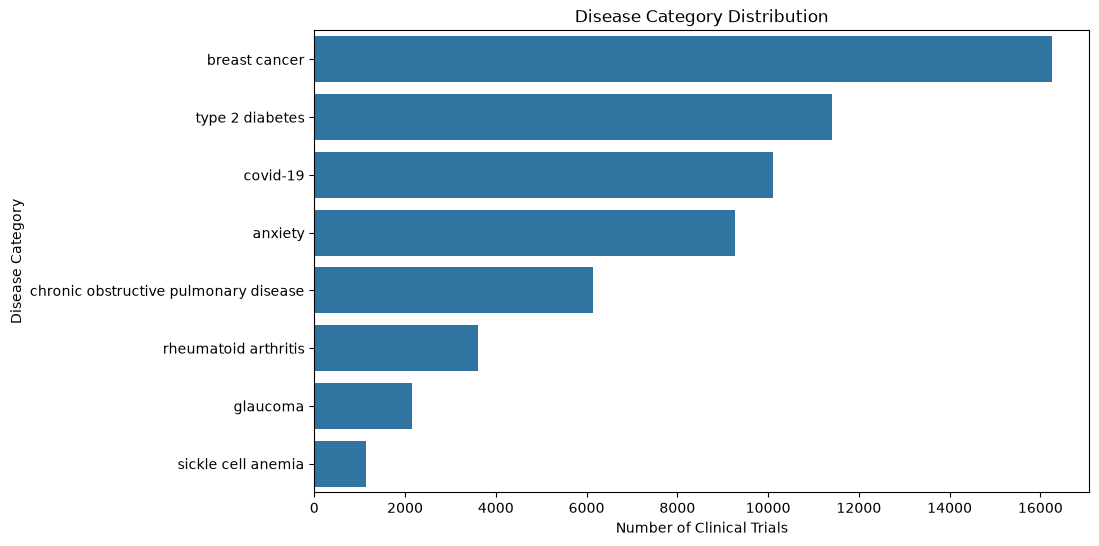

In [51]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='disease_category',
    data=clinical_nlp,
    order=clinical_nlp['disease_category'].value_counts().index
)

plt.title("Disease Category Distribution")
plt.xlabel("Number of Clinical Trials")
plt.ylabel("Disease Category")

plt.show()

In [52]:
clinical_nlp['summary_length'] = clinical_nlp['summary'].str.len()

clinical_nlp['summary_length'].describe()

count    60072.000000
mean       689.583300
std        631.121976
min         17.000000
25%        253.000000
50%        467.000000
75%        906.000000
max       5011.000000
Name: summary_length, dtype: float64

In [53]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [54]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [55]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [56]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [ ]:
clinical_nlp['clean_summary'] = clinical_nlp['summary'].apply(clean_text)